# Experiment: Subtask 1 Visual Review

Objective:
- Load saved Subtask 1 vision artifacts and review ground truth vs predictions without rerunning training.
- Surface the class legend, confusion patterns, confidence, and worst/best validation patches so VB can make a fast submission gate decision.

Success criteria:
- The notebook opens one `run_id`, shows the exported train/val/test panels, and highlights failure modes that are easy to miss in the raw ZIP.
- Every plot is derived from saved artifacts in `results/subtask1/`.


## Setup

Keep this notebook as a visual inspection tool. Training and inference remain in scripts; the notebook only reads saved artifacts.


In [36]:
from __future__ import annotations

import csv
import json
import math
from collections import Counter
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display

REPO_ROOT = None
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / 'scripts').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Run this notebook from the ai4agri repository root or a child directory')

RESULTS_DIR = REPO_ROOT / 'results' / 'subtask1'
RUNS_CSV = REPO_ROOT / 'results' / 'runs.csv'

# Model-space classes 0-4 (raw labels shifted by -1 after fix; pre-fix runs: raw 0=nodata was class 0, raw 5=Very High excluded)
CLASS_NAMES = ['Very Low (0)', 'Low (1)', 'Medium (2)', 'High (3)', 'Very High (4)']
DISPLAY_CLASS_NAMES = [*CLASS_NAMES, 'Nodata / boundary']  # display index 5; raw value 5 (old) or 255->5 via display_mask (new)
CLASS_COLORS = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850', '#7f7f7f']
SCORED_CLASS_COLORS = CLASS_COLORS[:5]
CLASS_COLOR_MAP = {idx: color for idx, color in enumerate(CLASS_COLORS)}
TOLERANCE_LABELS = ['Exact', 'Within +/-1', 'Miss >1', 'Ignored']
TOLERANCE_COLORS = ['#1a9850', '#fee08b', '#d73027', '#4d4d4d']

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.size'] = 10

RUN_ID ='existing_unet_ce_summary_rand_e10_p1024_v256_m5'
#RUN_ID = 'existing_unet_ce_summary_rand_e8_p2048_v512_m5'
# Other useful comparison runs:
# RUN_ID = 'existing_unet_ce_summary_rand_e10_p1024_v256_m5'
# RUN_ID = 'existing_unet_wce_summary_rand_e6_p512_v128_m5'
# RUN_ID = 'existing_unet_wce_mild_summary_rand_e6_p512_v128_m5'

VISION_RUN_DIR = RESULTS_DIR / 'vision_runs' / RUN_ID
VISION_VISUAL_DIR = RESULTS_DIR / 'visuals' / RUN_ID
VISION_VAL_PROBS = RESULTS_DIR / 'val_preds' / f'{RUN_ID}_val_probs.npz'
VISION_ZIP = RESULTS_DIR / 'submissions' / f'{RUN_ID}.zip'


def load_json(path: Path) -> dict:
    return json.loads(path.read_text()) if path.exists() else {}


def show_table(df: pd.DataFrame, rows: int = 10):
    if df.empty:
        print('No rows to show.')
        return
    display(df.head(rows))


def image_grid(paths, title: str, columns: int = 4, figsize=(16, 10)):
    paths = [Path(p) for p in paths]
    if not paths:
        print(f'No images found for {title}.')
        return
    rows = int(math.ceil(len(paths) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=figsize)
    axes = np.atleast_1d(axes).reshape(rows, columns)
    for ax in axes.ravel():
        ax.axis('off')
    for ax, path in zip(axes.ravel(), paths):
        ax.imshow(Image.open(path))
        ax.set_title(path.stem.replace('_', ' '), fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def build_panel_index(visual_dir: Path, prefix: str) -> dict[str, Path]:
    index: dict[str, Path] = {}
    if not visual_dir.exists():
        return index
    for path in sorted(visual_dir.glob(f'{prefix}_*.png')):
        stem = path.stem
        rest = stem[len(prefix) + 1:]
        _, patch_id = rest.split('_', 1)
        index[patch_id] = path
    return index


def load_validation_payload(path: Path):
    if not path.exists():
        return None
    payload = np.load(path, allow_pickle=True)
    return {key: payload[key] for key in payload.files}


def display_mask(mask):
    display_mask_array = np.asarray(mask, dtype=np.int16).copy()
    display_mask_array[display_mask_array == 255] = 5
    return display_mask_array


def accuracy_pm1_display(y_true, y_pred):
    true = np.asarray(y_true, dtype=np.int16)
    pred = np.asarray(y_pred, dtype=np.int16)
    valid = (true >= 0) & (true <= 4) & (pred >= 0) & (pred <= 4)
    diff = np.abs(true - pred)
    display_array = np.full(true.shape, 3, dtype=np.uint8)
    display_array[valid & (diff > 1)] = 2
    display_array[valid & (diff == 1)] = 1
    display_array[valid & (diff == 0)] = 0
    return display_array


def add_tolerance_legend(ax):
    handles = [
        mpatches.Patch(facecolor=color, edgecolor='black', linewidth=0.3, label=label)
        for label, color in zip(TOLERANCE_LABELS, TOLERANCE_COLORS)
    ]
    ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False, fontsize=8)


print('Repo root:', REPO_ROOT)
print('Run id:', RUN_ID)
print('Run dir exists:', VISION_RUN_DIR.exists())
print('Visual dir exists:', VISION_VISUAL_DIR.exists())
print('Validation payload exists:', VISION_VAL_PROBS.exists())
print('Submission zip exists:', VISION_ZIP.exists())


Repo root: /Users/vb/dev/projects/ai4agri
Run id: existing_unet_ce_summary_rand_e10_p1024_v256_m5
Run dir exists: True
Visual dir exists: True
Validation payload exists: True
Submission zip exists: True


## Run Summary

This table gives the recorded metrics and the tracking note for the selected run. It is the quick gate before looking at images.


In [37]:
run_rows = []
if RUNS_CSV.exists():
    with RUNS_CSV.open() as handle:
        for row in csv.DictReader(handle):
            if row['run_id'] == RUN_ID:
                run_rows.append(row)

run_summary = pd.DataFrame(run_rows)
if not run_summary.empty:
    display(run_summary.T)
else:
    print('No matching row found in results/runs.csv for this run_id.')

config = load_json(VISION_RUN_DIR / 'config.json')
metrics = load_json(VISION_RUN_DIR / 'metrics.json')
history_path = VISION_RUN_DIR / 'metrics_history.json'
history = load_json(history_path).get('history', []) if history_path.exists() else []

summary = {
    'run_id': RUN_ID,
    'best_epoch': metrics.get('best_epoch'),
    'accuracy_pm1': metrics.get('accuracy_pm1'),
    'exact_accuracy': metrics.get('exact_accuracy'),
    'mean_absolute_error': metrics.get('mean_absolute_error'),
    'elapsed_seconds': metrics.get('elapsed_seconds'),
    'train_epochs_logged': len(history),
}
print(pd.Series(summary).to_string())


,0
run_id,existing_unet_ce_summary_rand_e10_p1024_v256_m5
created_at,2026-05-05T09:46:20Z
owner,Codex
venue,RunPod RTX PRO 4500
subtask,subtask1
phase,vision-candidate
command,python scripts/run_subtask1_vision.py train --...
status,validated_zip
metric_name,accuracy_pm1
metric_value,0.7278788585595585


run_id                 existing_unet_ce_summary_rand_e10_p1024_v256_m5
best_epoch                                                           2
accuracy_pm1                                                  0.727879
exact_accuracy                                                0.432542
mean_absolute_error                                           1.116915
elapsed_seconds                                               1310.791
train_epochs_logged                                                  4


## Class Legend

Use this legend while reading the GT and prediction panels. The label colors match the ordinal palette used in the exported visual artifacts.


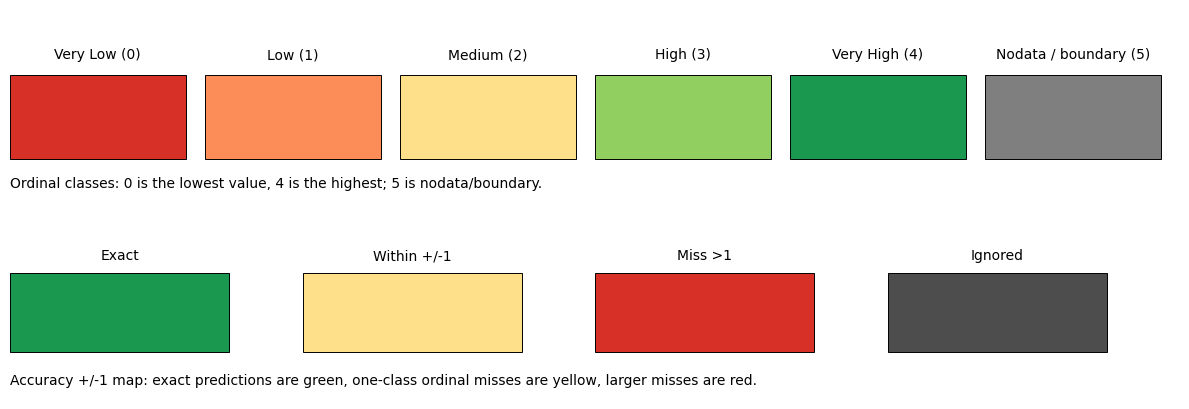

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4.2), gridspec_kw={'height_ratios': [1, 1]})
for ax in axes:
    ax.axis('off')

axes[0].set_xlim(0, 6)
axes[0].set_ylim(0, 1)
for idx, (name, color) in enumerate(zip(DISPLAY_CLASS_NAMES, CLASS_COLORS)):
    axes[0].add_patch(plt.Rectangle((idx, 0.2), 0.9, 0.45, color=color, ec='black', lw=0.7))
    axes[0].text(idx + 0.45, 0.72, name, ha='center', va='bottom', fontsize=10)
axes[0].text(0, 0.05, 'Ordinal classes: 0 is the lowest value, 4 is the highest; 5 is nodata/boundary.', fontsize=10)

axes[1].set_xlim(0, 4)
axes[1].set_ylim(0, 1)
for idx, (name, color) in enumerate(zip(TOLERANCE_LABELS, TOLERANCE_COLORS)):
    axes[1].add_patch(plt.Rectangle((idx, 0.25), 0.75, 0.42, color=color, ec='black', lw=0.7))
    axes[1].text(idx + 0.375, 0.73, name, ha='center', va='bottom', fontsize=10)
axes[1].text(0, 0.08, 'Accuracy +/-1 map: exact predictions are green, one-class ordinal misses are yellow, larger misses are red.', fontsize=10)

plt.tight_layout()
plt.show()


## Validation Diagnostics

The payload contains `y_true`, `y_pred`, and `probs`. That lets us plot the confusion matrix, class frequencies, patch-level error, exact accuracy, Accuracy +/-1, and confidence without touching the model code.


Validation pixel counts by class (truth): {0: 1808033, 1: 540564, 2: 462220, 3: 510296, 4: 494592}
Validation pixel counts by class (pred):   {0: 1687571, 1: 897268, 2: 61840, 3: 7581, 4: 1540044}
Ignored pixels (label 255 or invalid): 378599
Global exact accuracy: 0.4325
Global Accuracy +/-1: 0.7279
Global MAE: 1.1169
Patches with valid scored pixels: 253 of 256
Patch-level Accuracy +/-1:
count    253.000000
mean       0.713698
std        0.238523
min        0.006213
25%        0.590088
50%        0.745107
75%        0.909912
max        1.000000
Patch-level mean absolute error:
count    253.000000
mean       1.169137
std        0.818080
min        0.000000
25%        0.619934
50%        1.067078
75%        1.437988
max        3.974746


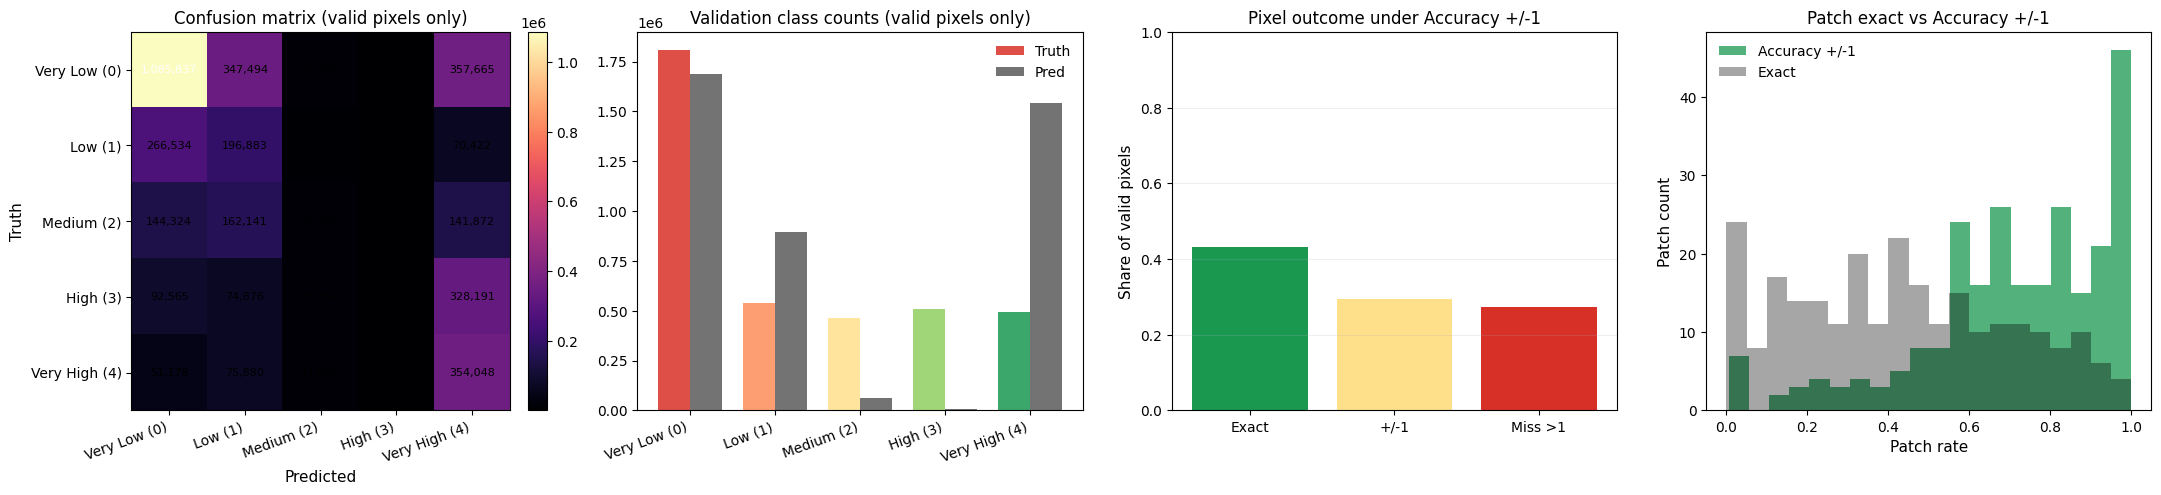

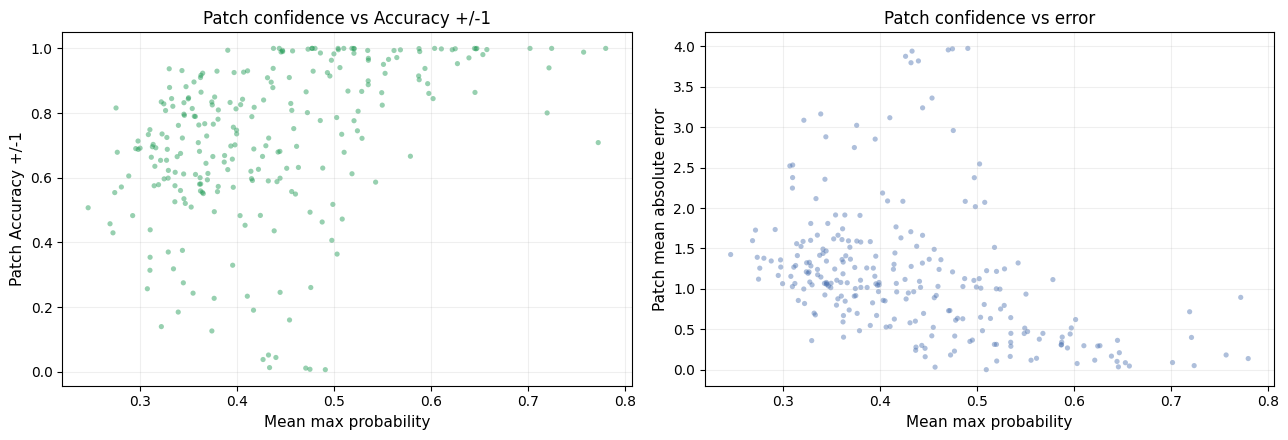

,patch_id,valid_pixels,mae,exact_rate,accuracy_pm1,miss_gt1_rate,mean_conf,entropy
0,8832_14144,14968,3.974746,0.006213,0.006213,0.993787,0.490722,1.319473
1,11904_8960,15280,3.969175,0.007395,0.007395,0.992605,0.474879,1.347494
2,8256_14336,10764,3.956150,0.010962,0.010962,0.989038,0.470540,1.343983
3,6400_16640,12081,3.940816,0.012582,0.012582,0.987418,0.433218,1.404243
4,12800_8192,14804,3.876858,0.006350,0.037557,0.962443,0.426518,1.413565
5,6464_16640,13370,3.819447,0.032162,0.043904,0.956096,0.439765,1.389377
6,8320_14336,6332,3.797378,0.048168,0.051485,0.948515,0.432127,1.396176
7,14848_5760,270,2.748148,0.000000,0.125926,0.874074,0.373735,1.460570
8,6016_17216,7591,3.085759,0.062969,0.139376,0.860624,0.321644,1.524485
9,8832_14208,11245,3.360427,0.159893,0.159893,0.840107,0.453809,1.372752


,patch_id,valid_pixels,mae,exact_rate,accuracy_pm1,miss_gt1_rate,mean_conf,entropy
252,12928_7424,1479,0.000000,1.000000,1.0,0.0,0.509754,1.294744
251,9600_320,16384,0.050049,0.949951,1.0,0.0,0.724107,0.867221
250,8576_3584,16384,0.075806,0.924194,1.0,0.0,0.603414,1.060629
249,9600_384,16384,0.088074,0.911926,1.0,0.0,0.701787,0.903491
248,8512_3584,16384,0.102051,0.897949,1.0,0.0,0.644575,0.987036
247,9344_64,16384,0.137451,0.862549,1.0,0.0,0.779838,0.735007
246,4160_12864,16384,0.209534,0.790466,1.0,0.0,0.646956,1.006397
245,6144_13184,14984,0.229645,0.770355,1.0,0.0,0.476936,1.292230
244,9984_10240,16384,0.279175,0.720825,1.0,0.0,0.437248,1.317811
243,12032_256,16384,0.299927,0.700073,1.0,0.0,0.443249,1.327944


In [39]:
val_payload = load_validation_payload(VISION_VAL_PROBS)
if val_payload is None:
    print(f'Missing validation payload: {VISION_VAL_PROBS}')
else:
    patch_ids = val_payload['patch_ids']
    probs = val_payload['probs'].astype(np.float32)
    y_true = val_payload['y_true'].astype(np.int16)
    y_pred = val_payload['y_pred'].astype(np.int16)

    valid_true = (y_true >= 0) & (y_true <= 4)  # exclude nodata: value 5 (pre-fix) or 255 (post-fix)
    valid_pred = (y_pred >= 0) & (y_pred <= 4)
    valid = valid_true & valid_pred
    valid_counts = valid.sum(axis=(1, 2))
    diff = np.abs(y_true - y_pred)

    exact_pixels = (diff == 0) & valid
    pm1_pixels = (diff <= 1) & valid
    miss_gt1_pixels = (diff > 1) & valid
    abs_err = np.where(valid, diff, np.nan)

    patch_mae = np.divide(
        np.where(valid, diff, 0).sum(axis=(1, 2)),
        valid_counts,
        out=np.full(len(valid_counts), np.nan, dtype=np.float64),
        where=valid_counts > 0,
    )
    patch_exact = np.divide(
        exact_pixels.sum(axis=(1, 2)),
        valid_counts,
        out=np.full(len(valid_counts), np.nan, dtype=np.float64),
        where=valid_counts > 0,
    )
    patch_pm1 = np.divide(
        pm1_pixels.sum(axis=(1, 2)),
        valid_counts,
        out=np.full(len(valid_counts), np.nan, dtype=np.float64),
        where=valid_counts > 0,
    )
    patch_miss_gt1 = np.divide(
        miss_gt1_pixels.sum(axis=(1, 2)),
        valid_counts,
        out=np.full(len(valid_counts), np.nan, dtype=np.float64),
        where=valid_counts > 0,
    )
    patch_conf = probs.max(axis=1).mean(axis=(1, 2))
    patch_entropy = (-(probs * np.log(np.clip(probs, 1e-6, 1.0))).sum(axis=1)).mean(axis=(1, 2))

    true_counts = np.bincount(y_true[valid_true].ravel(), minlength=5)
    pred_counts = np.bincount(y_pred[valid_pred].ravel(), minlength=5)
    cm = np.zeros((5, 5), dtype=np.int64)
    for t, p in zip(y_true[valid].ravel(), y_pred[valid].ravel()):
        cm[int(t), int(p)] += 1

    valid_total = int(valid.sum())
    ignored = int((~valid_true).sum())
    global_exact = float(exact_pixels.sum() / valid_total) if valid_total else 0.0
    global_pm1 = float(pm1_pixels.sum() / valid_total) if valid_total else 0.0
    global_mae = float(np.nanmean(abs_err)) if valid_total else 0.0

    print('Validation pixel counts by class (truth):', dict(enumerate(true_counts.tolist())))
    print('Validation pixel counts by class (pred):  ', dict(enumerate(pred_counts.tolist())))
    print('Ignored pixels (label 255 or invalid):', ignored)
    print(f'Global exact accuracy: {global_exact:.4f}')
    print(f'Global Accuracy +/-1: {global_pm1:.4f}')
    print(f'Global MAE: {global_mae:.4f}')
    print('Patches with valid scored pixels:', int((valid_counts > 0).sum()), 'of', len(valid_counts))
    print('Patch-level Accuracy +/-1:')
    print(pd.Series(patch_pm1).dropna().describe().to_string())
    print('Patch-level mean absolute error:')
    print(pd.Series(patch_mae).dropna().describe().to_string())

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    im = axes[0].imshow(cm, cmap='magma')
    axes[0].set_title('Confusion matrix (valid pixels only)')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Truth')
    axes[0].set_xticks(range(5), CLASS_NAMES, rotation=20, ha='right')
    axes[0].set_yticks(range(5), CLASS_NAMES)
    for i in range(5):
        for j in range(5):
            axes[0].text(j, i, f'{cm[i, j]:,}', ha='center', va='center', color='white' if cm[i, j] > cm.max() * 0.4 else 'black', fontsize=8)
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    x = np.arange(5)
    width = 0.38
    axes[1].bar(x - width / 2, true_counts, width=width, color=SCORED_CLASS_COLORS, alpha=0.85, label='Truth')
    axes[1].bar(x + width / 2, pred_counts, width=width, color='black', alpha=0.55, label='Pred')
    axes[1].set_title('Validation class counts (valid pixels only)')
    axes[1].set_xticks(x, CLASS_NAMES, rotation=20, ha='right')
    axes[1].legend(frameon=False)

    axes[2].bar(['Exact', '+/-1', 'Miss >1'], [global_exact, global_pm1 - global_exact, 1.0 - global_pm1], color=TOLERANCE_COLORS[:3])
    axes[2].set_ylim(0, 1)
    axes[2].set_title('Pixel outcome under Accuracy +/-1')
    axes[2].set_ylabel('Share of valid pixels')
    axes[2].grid(axis='y', alpha=0.2)

    axes[3].hist(patch_pm1, bins=20, color='#1a9850', alpha=0.75, label='Accuracy +/-1')
    axes[3].hist(patch_exact, bins=20, color='black', alpha=0.35, label='Exact')
    axes[3].set_title('Patch exact vs Accuracy +/-1')
    axes[3].set_xlabel('Patch rate')
    axes[3].set_ylabel('Patch count')
    axes[3].axvline(float(np.median(patch_pm1)), color='#1a9850', ls='--', lw=1)
    axes[3].legend(frameon=False)

    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(patch_conf, patch_pm1, s=14, alpha=0.45, color='#1a9850', edgecolors='none')
    axes[0].set_title('Patch confidence vs Accuracy +/-1')
    axes[0].set_xlabel('Mean max probability')
    axes[0].set_ylabel('Patch Accuracy +/-1')
    axes[0].grid(alpha=0.2)

    axes[1].scatter(patch_conf, patch_mae, s=14, alpha=0.45, color='#4c72b0', edgecolors='none')
    axes[1].set_title('Patch confidence vs error')
    axes[1].set_xlabel('Mean max probability')
    axes[1].set_ylabel('Patch mean absolute error')
    axes[1].grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

    stats = pd.DataFrame({
        'patch_id': patch_ids,
        'valid_pixels': valid_counts,
        'mae': patch_mae,
        'exact_rate': patch_exact,
        'accuracy_pm1': patch_pm1,
        'miss_gt1_rate': patch_miss_gt1,
        'mean_conf': patch_conf,
        'entropy': patch_entropy,
    })
    stats_valid = stats[stats['valid_pixels'] > 0].copy()
    stats_valid = stats_valid.sort_values(['accuracy_pm1', 'mae'], ascending=[True, False]).reset_index(drop=True)
    display(stats_valid.head(10))
    display(stats_valid.sort_values(['accuracy_pm1', 'mae'], ascending=[False, True]).head(10))


## Accuracy +/-1 Maps

These maps use the scoring tolerance directly: green is exact, yellow is within one ordinal class and still counts for Accuracy +/-1, red is a larger miss, and dark gray is ignored nodata/boundary.


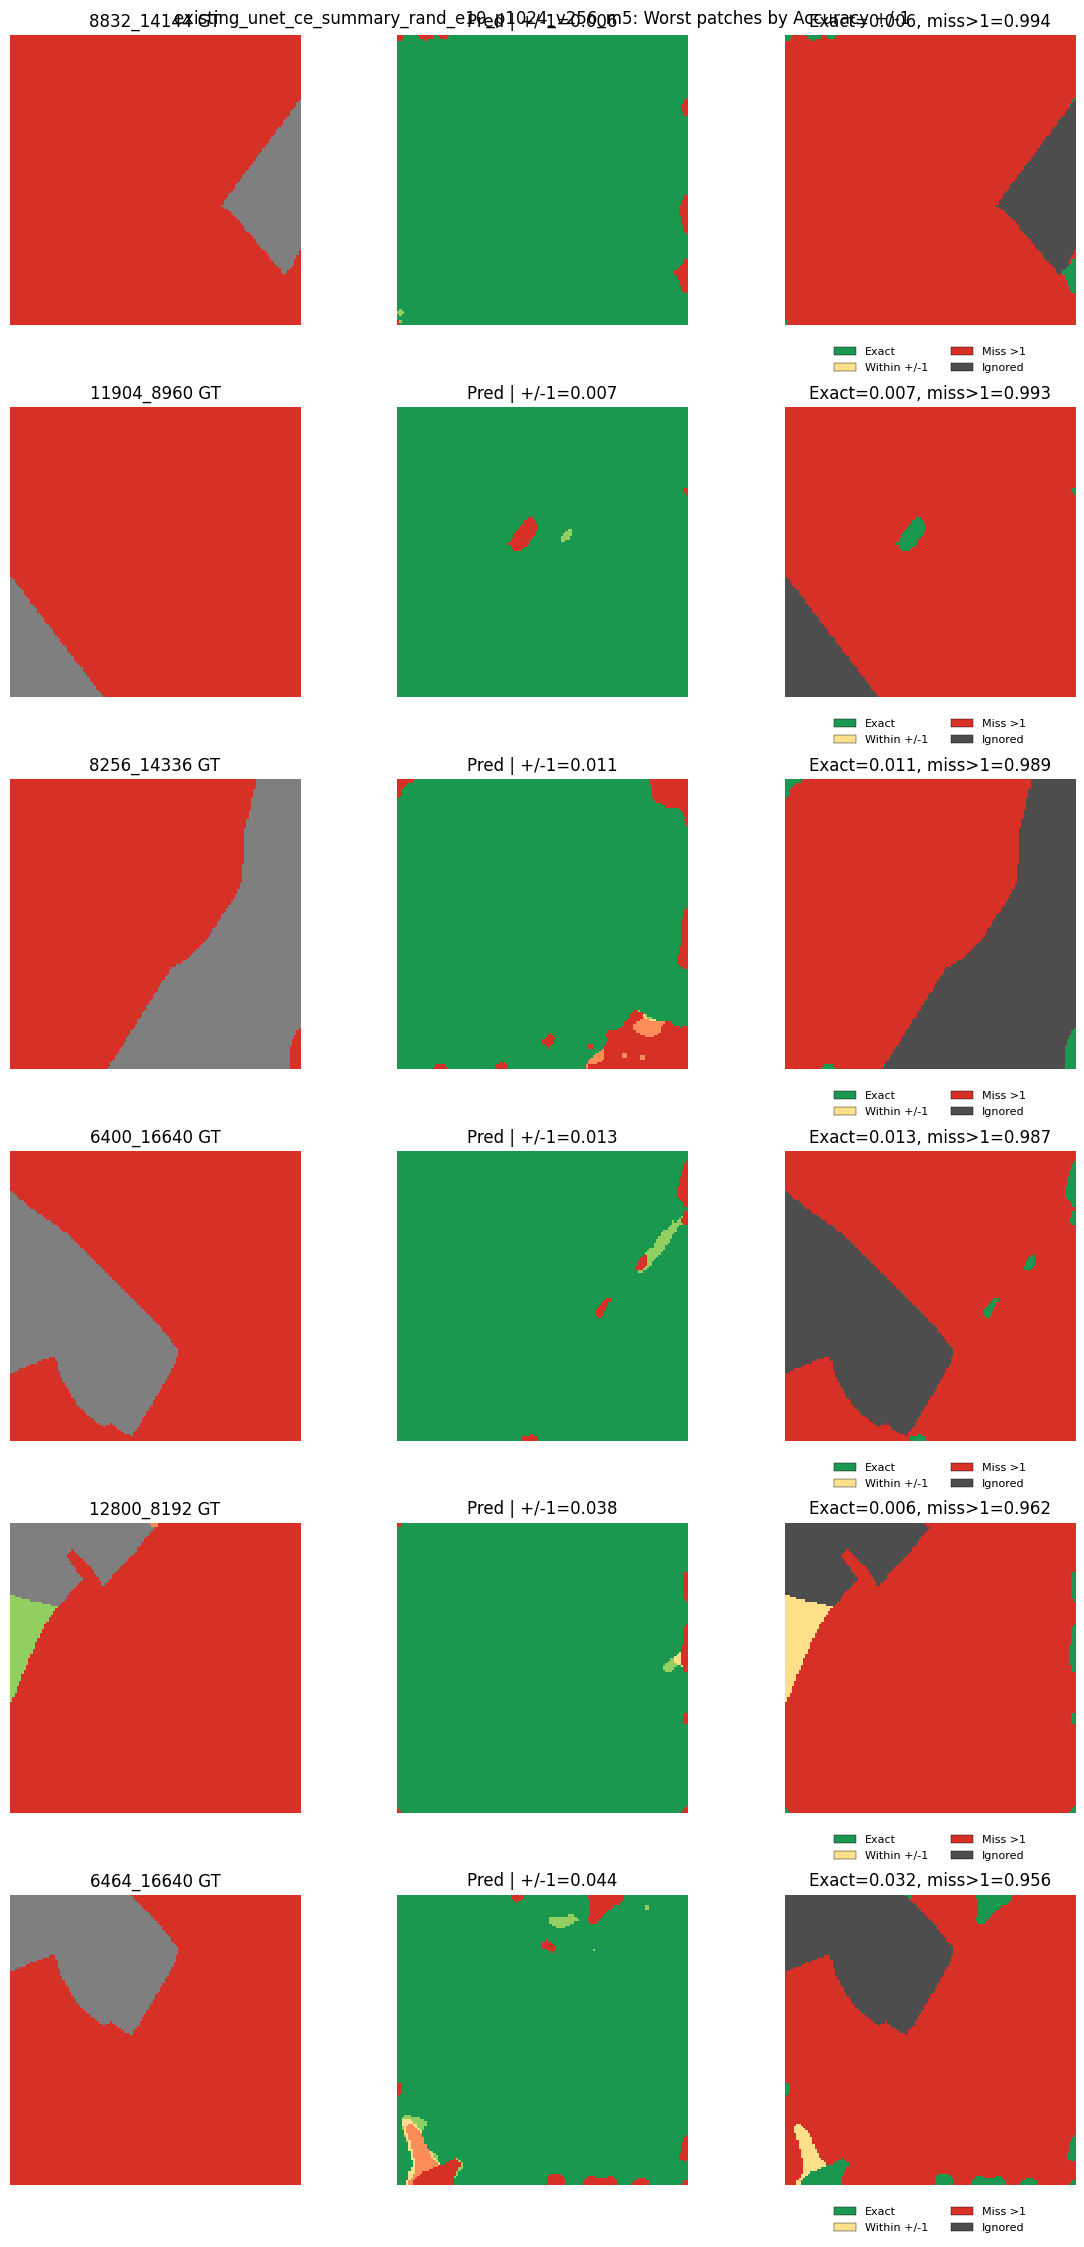

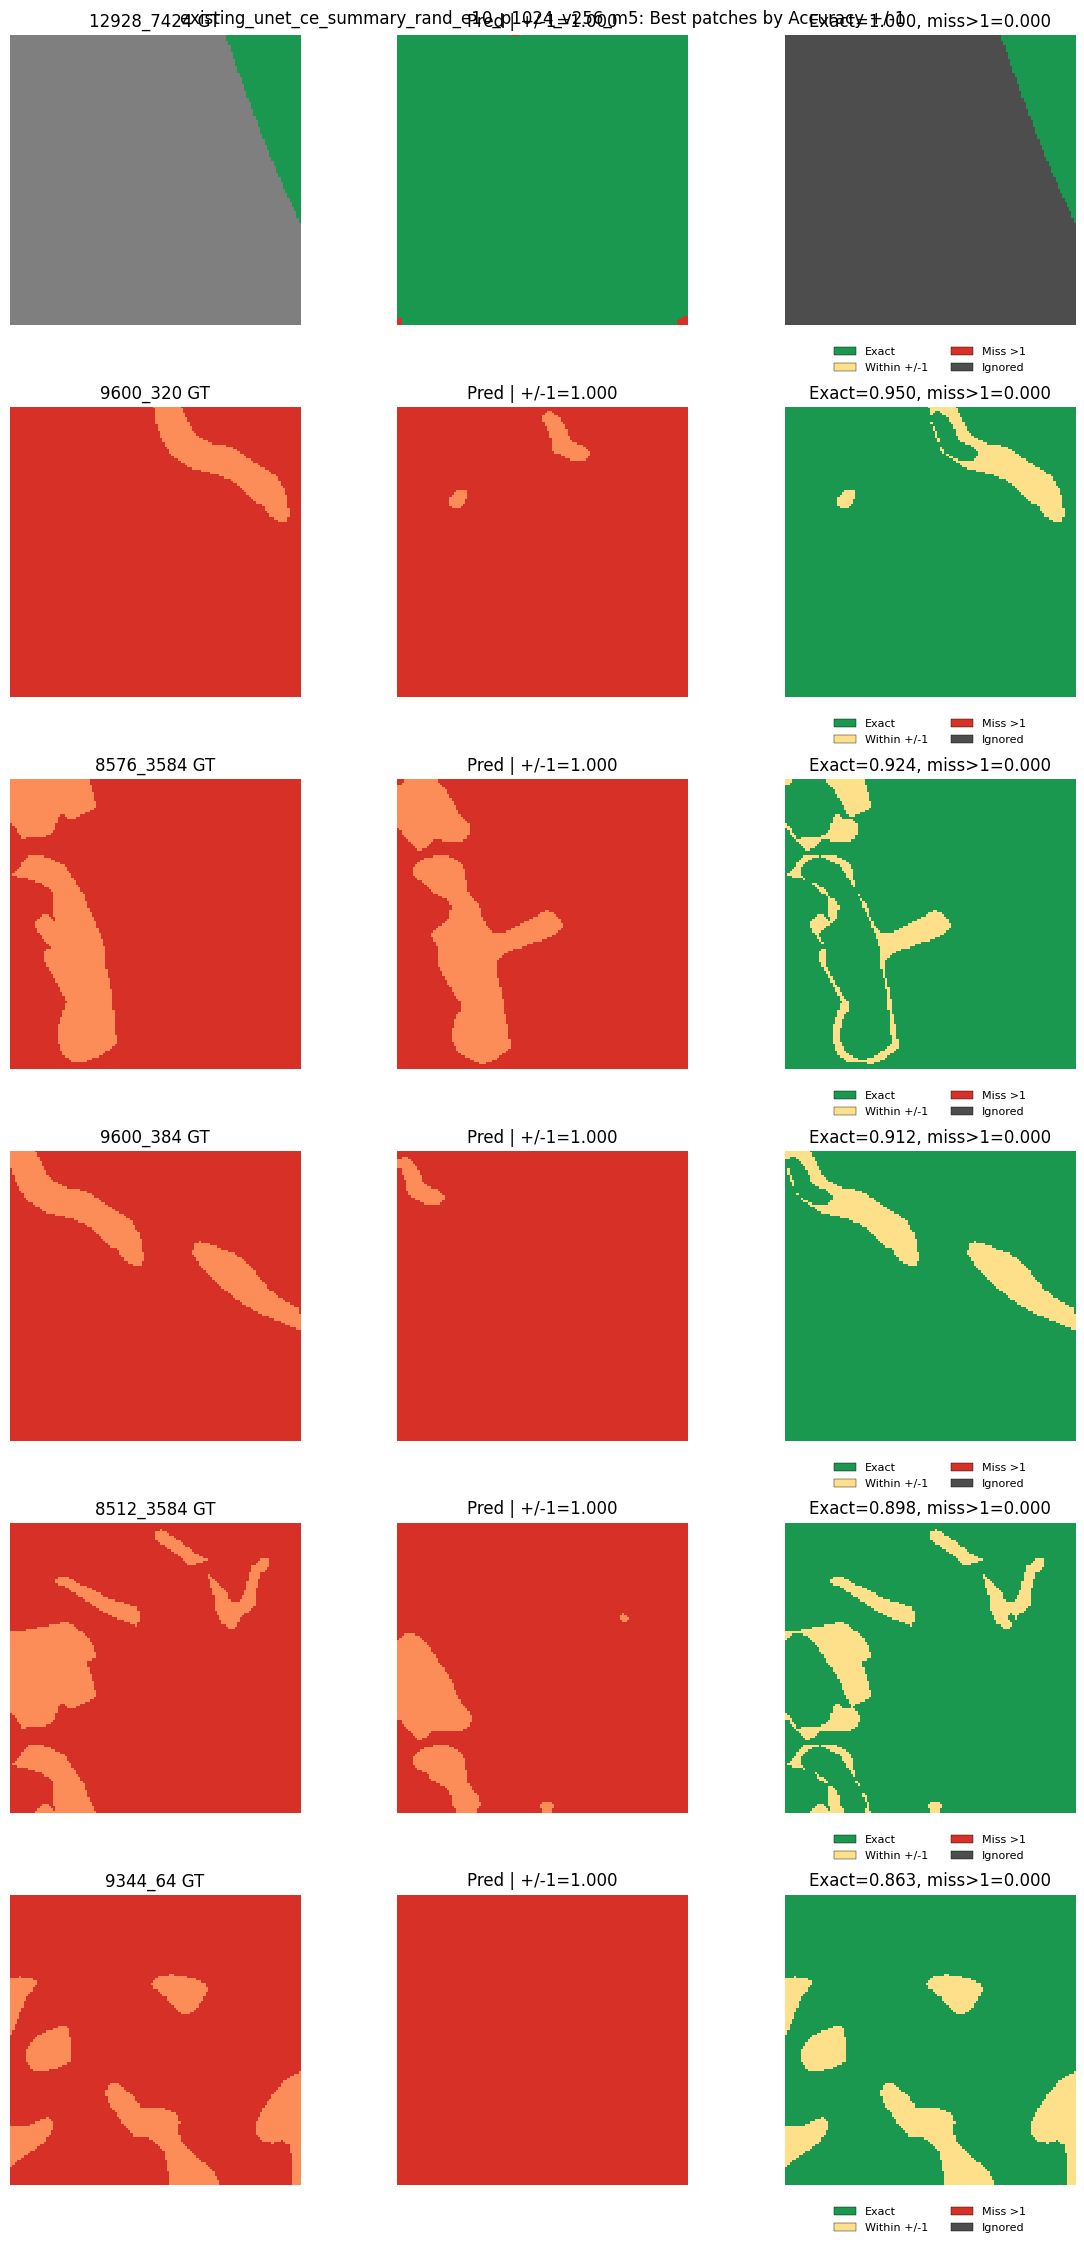

In [40]:
if val_payload is None:
    print('Load the validation payload first.')
else:
    def plot_tolerance_examples(example_stats, title, limit=6):
        rows = min(limit, len(example_stats))
        fig, axes = plt.subplots(rows, 3, figsize=(12, 3.8 * rows))
        axes = np.atleast_2d(axes)
        class_cmap = plt.matplotlib.colors.ListedColormap(CLASS_COLORS)
        tol_cmap = plt.matplotlib.colors.ListedColormap(TOLERANCE_COLORS)
        for row_idx, row in enumerate(example_stats.head(rows).itertuples(index=False)):
            patch_idx = int(np.where(patch_ids == row.patch_id)[0][0])
            axes[row_idx, 0].imshow(display_mask(y_true[patch_idx]), cmap=class_cmap, vmin=0, vmax=5, interpolation='nearest')
            axes[row_idx, 0].set_title(f'{row.patch_id} GT')
            axes[row_idx, 1].imshow(display_mask(y_pred[patch_idx]), cmap=class_cmap, vmin=0, vmax=5, interpolation='nearest')
            axes[row_idx, 1].set_title(f'Pred | +/-1={row.accuracy_pm1:.3f}')
            axes[row_idx, 2].imshow(accuracy_pm1_display(y_true[patch_idx], y_pred[patch_idx]), cmap=tol_cmap, vmin=0, vmax=3, interpolation='nearest')
            axes[row_idx, 2].set_title(f'Exact={row.exact_rate:.3f}, miss>1={row.miss_gt1_rate:.3f}')
            add_tolerance_legend(axes[row_idx, 2])
            for ax in axes[row_idx]:
                ax.axis('off')
        fig.suptitle(title)
        fig.tight_layout()
        plt.show()

    worst_pm1 = stats_valid.sort_values(['accuracy_pm1', 'mae'], ascending=[True, False])
    best_pm1 = stats_valid.sort_values(['accuracy_pm1', 'mae'], ascending=[False, True])
    plot_tolerance_examples(worst_pm1, f'{RUN_ID}: Worst patches by Accuracy +/-1')
    plot_tolerance_examples(best_pm1, f'{RUN_ID}: Best patches by Accuracy +/-1')


## Visual Panels

The exported PNGs already combine the Sentinel composite, ground truth, prediction, and absolute error. The notebook sorts them by patch-level error so the worst cases are easy to inspect first.


Worst patches: ['8832_14144', '11904_8960', '8256_14336', '6400_16640', '12800_8192']
No images found for existing_unet_ce_summary_rand_e10_p1024_v256_m5: Worst validation patches by Accuracy +/-1.
No images found for existing_unet_ce_summary_rand_e10_p1024_v256_m5: Best validation patches by Accuracy +/-1.
No images found for existing_unet_ce_summary_rand_e10_p1024_v256_m5: Random validation patches.


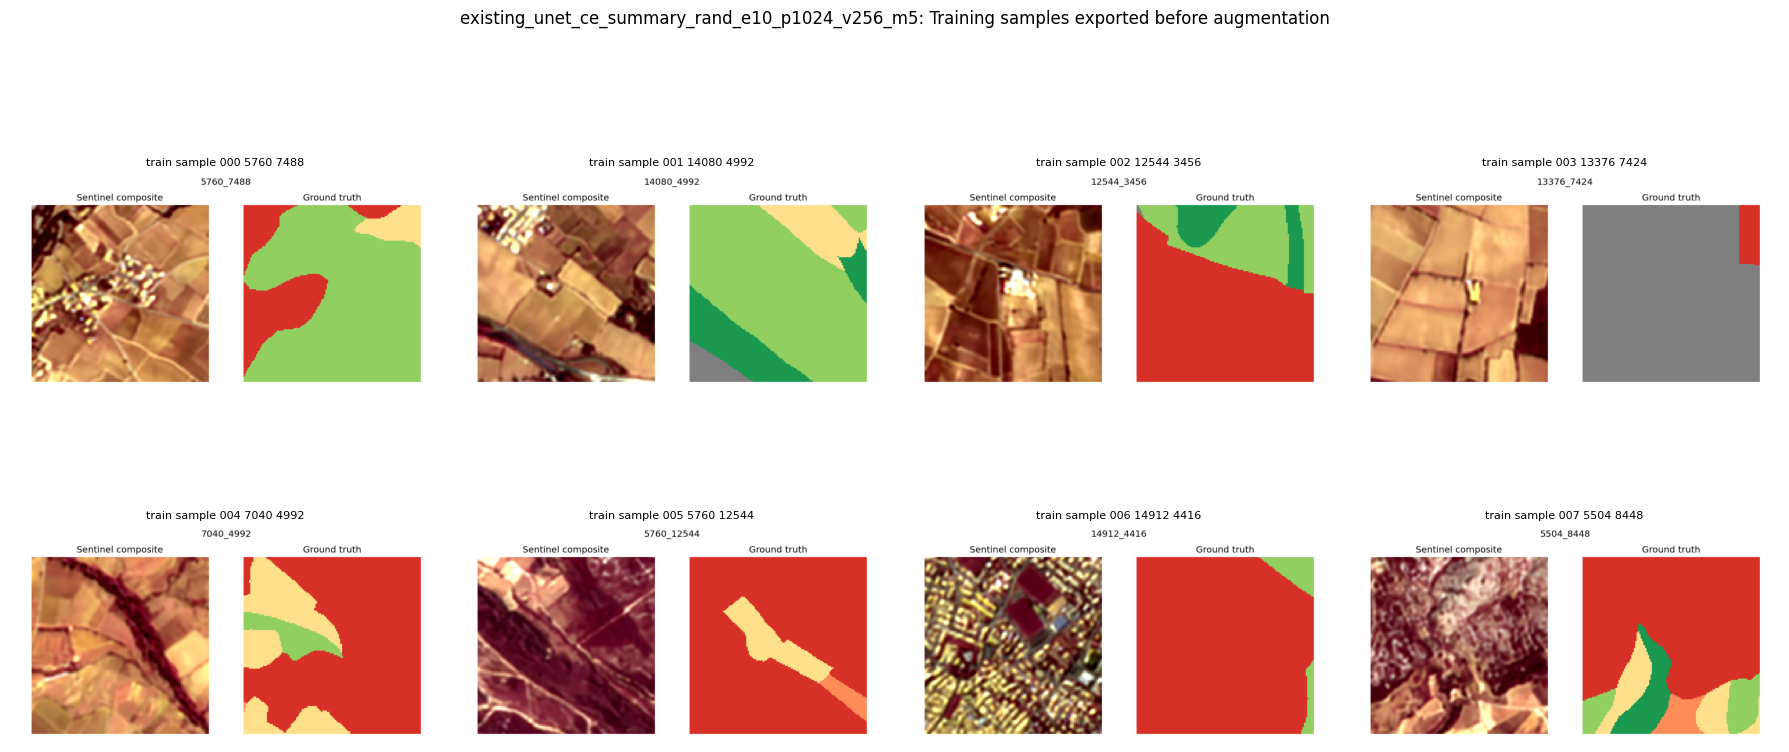

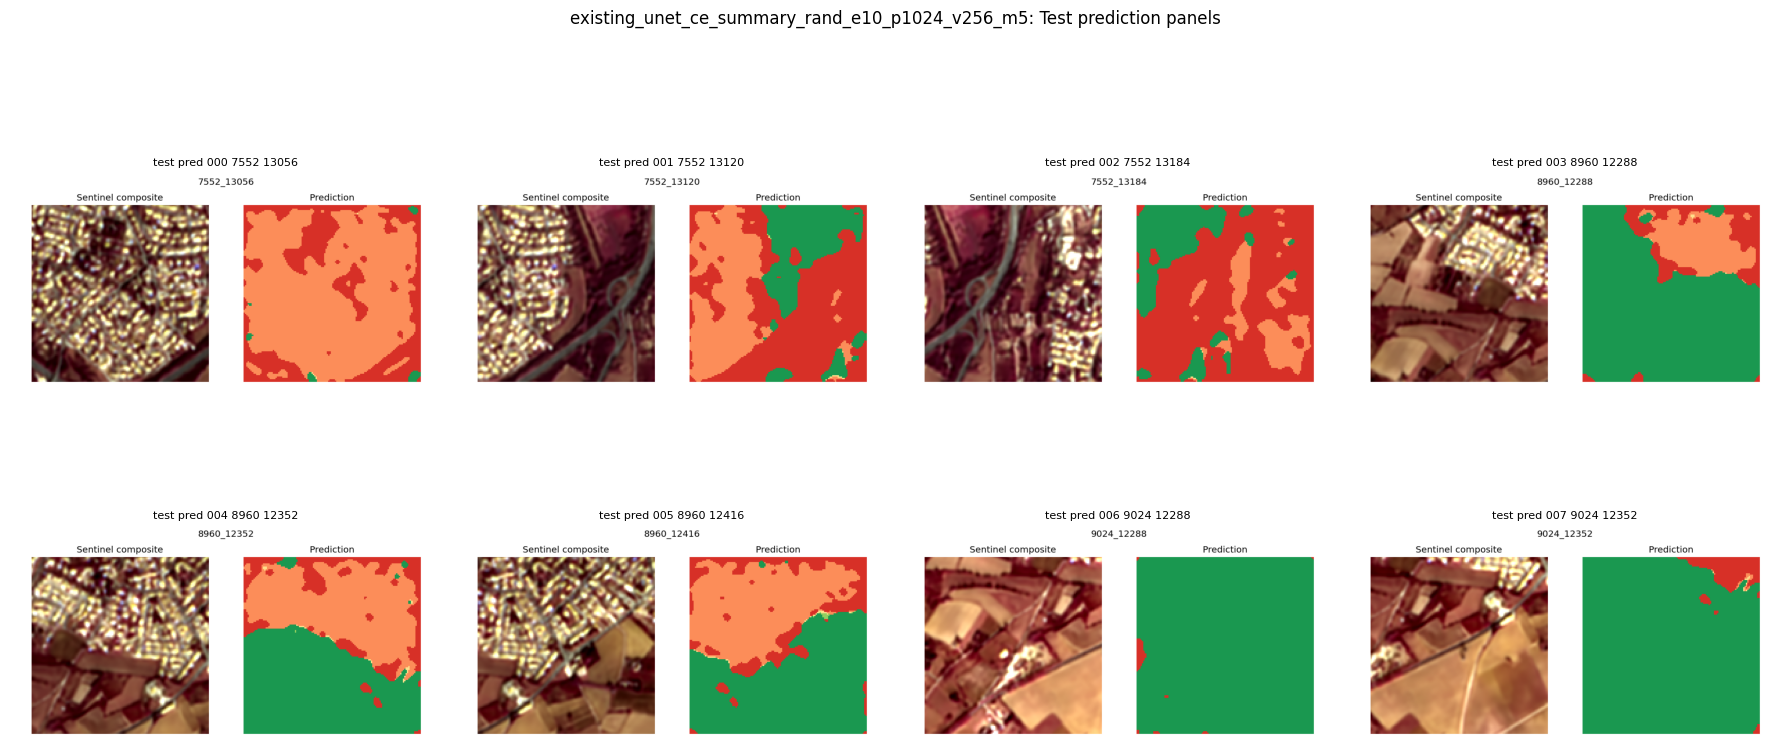

In [41]:
if val_payload is None:
    print('Load the validation payload first.')
else:
    panel_index = build_panel_index(VISION_VISUAL_DIR, 'val_pred')
    train_index = build_panel_index(VISION_VISUAL_DIR, 'train_sample')
    test_index = build_panel_index(VISION_VISUAL_DIR, 'test_pred')

    def panel_paths_for(ids, index):
        return [index[patch_id] for patch_id in ids if patch_id in index]

    worst_ids = stats_valid.sort_values(['accuracy_pm1', 'mae'], ascending=[True, False]).head(12)['patch_id'].tolist()
    best_ids = stats_valid.sort_values(['accuracy_pm1', 'mae'], ascending=[False, True]).head(12)['patch_id'].tolist()
    random_ids = stats_valid.sample(min(12, len(stats_valid)), random_state=7)['patch_id'].tolist()

    print('Worst patches:', worst_ids[:5])
    image_grid(panel_paths_for(worst_ids, panel_index), f'{RUN_ID}: Worst validation patches by Accuracy +/-1', columns=2, figsize=(16, 24))
    image_grid(panel_paths_for(best_ids, panel_index), f'{RUN_ID}: Best validation patches by Accuracy +/-1', columns=2, figsize=(16, 24))
    image_grid(panel_paths_for(random_ids, panel_index), f'{RUN_ID}: Random validation patches', columns=2, figsize=(16, 24))

    image_grid(sorted(train_index.values())[:8], f'{RUN_ID}: Training samples exported before augmentation', columns=4, figsize=(18, 9))
    image_grid(sorted(test_index.values())[:8], f'{RUN_ID}: Test prediction panels', columns=4, figsize=(18, 9))


## Optional Submission Check

If the run also wrote a ZIP, compare the file metadata here before any upload. Visual review should happen before submission, not after.


In [42]:
if VISION_ZIP.exists():
    print('Submission ZIP:', VISION_ZIP)
    print('Size bytes:', VISION_ZIP.stat().st_size)
else:
    print('No ZIP found for this run.')


Submission ZIP: /Users/vb/dev/projects/ai4agri/results/subtask1/submissions/existing_unet_ce_summary_rand_e10_p1024_v256_m5.zip
Size bytes: 625864


## Notes

- Favor runs whose GT and prediction panels keep the ordinal ordering intact and do not collapse to a single dominant class.
- Use the worst-patch grid to look for systematic edge failures, class disappearance, and over-smoothed boundaries.
- Keep inference and validation in scripts; this notebook is only for the human review step.
